# Money Craft Project

### Accounts

One row per customer per active month. An account has closed (churned) when its rows stop — there is no churn column.

| column | description |
|---------------|--------------------------|
| customer_id |	Unique customer identifier. |
| month |	Calendar month, e.g. 2023-04. |
| acquisition_channel |	How the customer was won: Branch, Online, Comparison Site, Outbound, Referral or Broker/IFA. |
| region | UK region of the customer. |
| age_band | Customer age group. |
| account_tier | Packaged tier that month: Classic (£0), Silver (£11), Gold (£18) or Platinum (£28). Can change over time. |
| monthly_fee |	Fee charged that month (£). Zero on Classic, or while a fee-waiver promo is running. |
| joined_on_promo |	True if the customer joined on a 6-month fee-waiver promotion. |

### Closure

Recorded reasons for closed accounts — but only for some of them. This table is deliberately incomplete: many closures have no reason recorded.

| column |	description |
|--------|--------------|
| customer_id |	The customer who closed their account. |
| close_month |	Month the account was closed. |
| reason_code |	Recorded reason: Fees too high, Switched provider, Poor service, Unhappy with perks, Moved abroad, Bereavement or Unknown. |


### Spend

One row per month per channel: what we spent winning customers.

| column | description |
|--------|------------|
| month |	Calendar month. |
| channel	| Acquisition channel (matches acquisition_channel above). |
| spend_gbp |	Marketing spend in that channel that month (£). |



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
accounts = pd.read_csv('moneycraft_accounts.csv')

accounts.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False


## Account nulls

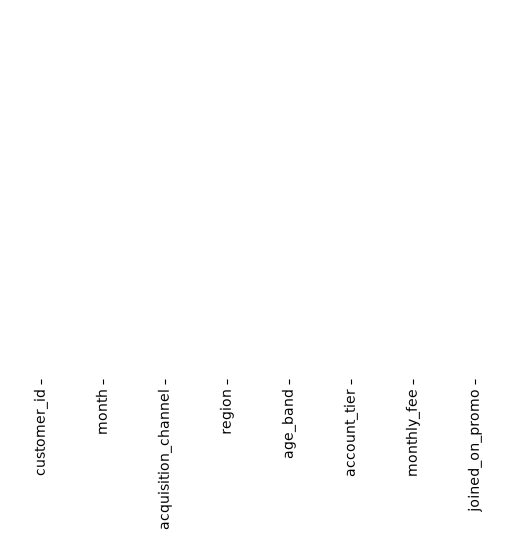

In [3]:
# any nulls/NaNs will appear as black lines
sns.heatmap(accounts.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [4]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 179018 entries, 0 to 179017
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          179018 non-null  int64
 1   month                179018 non-null  str  
 2   acquisition_channel  179018 non-null  str  
 3   region               179018 non-null  str  
 4   age_band             179018 non-null  str  
 5   account_tier         179018 non-null  str  
 6   monthly_fee          179018 non-null  int64
 7   joined_on_promo      179018 non-null  bool 
dtypes: bool(1), int64(2), str(5)
memory usage: 9.7 MB


In [5]:
accounts['month'] = pd.PeriodIndex(accounts['month'], freq='M')

In [6]:
accounts.describe(include='all')

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
count,179018.000000,179018,179018,179018,179018,179018,179018.000000,179018
unique,NaN,36,6,6,6,4,NaN,2
top,NaN,2024-12,Online,London,25-34,Silver,NaN,False
freq,NaN,9775,43906,42874,45265,57256,NaN,115271
mean,5474.700203,NaN,NaN,NaN,NaN,NaN,12.234200,NaN
std,3840.562809,NaN,NaN,NaN,NaN,NaN,9.807629,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,2209.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,4833.000000,NaN,NaN,NaN,NaN,NaN,11.000000,NaN
75%,8237.000000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN


In [7]:
accounts['month'].unique()

<PeriodArray>
['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07',
 '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02',
 '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09',
 '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04',
 '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11',
 '2024-12']
Length: 36, dtype: period[M]

Accounts data covers Jan 2022 - December 2024.

As per the description of the accounts dataset: 'One row per customer per active month. An account has closed (churned) when its rows stop'
>Any customer ids which do not have a 2024-12 month row can be considered to have churned.

In [8]:
closure = pd.read_csv('moneycraft_closure_reasons.csv')

closure.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


## Closure nulls

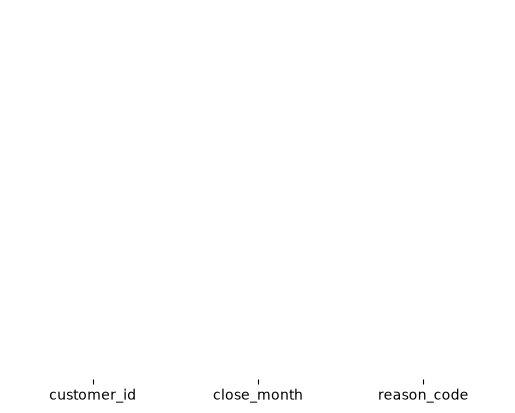

In [9]:
sns.heatmap(closure.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [10]:
closure.info()

<class 'pandas.DataFrame'>
RangeIndex: 4023 entries, 0 to 4022
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  4023 non-null   int64
 1   close_month  4023 non-null   str  
 2   reason_code  4023 non-null   str  
dtypes: int64(1), str(2)
memory usage: 94.4 KB


In [11]:
closure['close_month'] = pd.PeriodIndex(closure['close_month'], freq='M')

In [12]:
closure.describe(include='all')

,customer_id,close_month,reason_code
count,4023.000000,4023,4023
unique,NaN,36,7
top,NaN,2025-01,Fees too high
freq,NaN,211,1268
mean,5963.338802,NaN,NaN
std,3998.635024,NaN,NaN
min,1.000000,NaN,NaN
25%,2585.500000,NaN,NaN
50%,5374.000000,NaN,NaN
75%,8905.000000,NaN,NaN


The closure month column extends into Jan 2025 (the most recent date available). This means any customers who have a flagged close_month can also be considered as churned.

In [13]:
spend = pd.read_csv('moneycraft_marketing_spend.csv')

spend.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


## Spend nulls

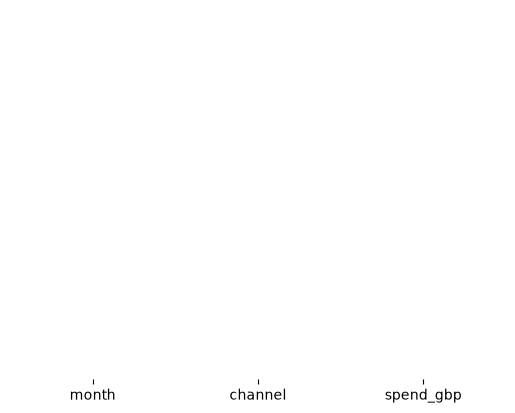

In [14]:
sns.heatmap(spend.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [15]:
spend.info()

<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      216 non-null    str    
 1   channel    216 non-null    str    
 2   spend_gbp  216 non-null    float64
dtypes: float64(1), str(2)
memory usage: 5.2 KB


In [16]:
spend['month'] = pd.PeriodIndex(spend['month'], freq='M')

In [17]:
spend.describe(include='all')

,month,channel,spend_gbp
count,216,216,216.000000
unique,36,6,NaN
top,2022-01,Branch,NaN
freq,6,36,NaN
mean,NaN,NaN,6368.518519
std,NaN,NaN,2846.043225
min,NaN,NaN,1526.000000
25%,NaN,NaN,4413.500000
50%,NaN,NaN,6036.500000
75%,NaN,NaN,8040.000000


## Sanity-check the headline claims against the data

Headline claims ~15,700 fee paying customers.

In [18]:
accounts['customer_id'].nunique()

15732

In [19]:
accounts['monthly_fee'].sum()

np.int64(2190142)

## Consolidating the Data

In [20]:
combined = pd.merge(left=accounts, right=closure, how='left', on='customer_id')

combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 179018 entries, 0 to 179017
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   customer_id          179018 non-null  int64    
 1   month                179018 non-null  period[M]
 2   acquisition_channel  179018 non-null  str      
 3   region               179018 non-null  str      
 4   age_band             179018 non-null  str      
 5   account_tier         179018 non-null  str      
 6   monthly_fee          179018 non-null  int64    
 7   joined_on_promo      179018 non-null  bool     
 8   close_month          32883 non-null   period[M]
 9   reason_code          32883 non-null   str      
dtypes: bool(1), int64(2), period[M](2), str(5)
memory usage: 12.5 MB


In [21]:
combined.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
1,2,2022-01,Online,London,55-64,Silver,11,False,NaT,NaN
2,3,2022-01,Branch,South East,25-34,Platinum,28,False,NaT,NaN
3,4,2022-01,Referral,London,25-34,Silver,0,True,NaT,NaN
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False,2022-11,Bereavement


In [22]:
combined['close_month'].max()

Period('2025-01', 'M')

In [23]:
# combined[combined['close_month'] == pd.Period('2025-01', 'M')]
combined[combined['customer_id'] == 376]


,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
640,376,2022-02,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
1179,376,2022-03,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
1989,376,2022-04,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
3059,376,2022-05,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
4392,376,2022-06,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
5973,376,2022-07,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
7825,376,2022-08,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
9977,376,2022-09,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
12410,376,2022-10,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
15105,376,2022-11,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown


## Single Customer View

In [24]:
combined = combined.sort_values(['customer_id', 'month'], ascending=[True, True])

combined.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider


In [25]:
combined[combined['customer_id'] == 8]

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
7,8,2022-01,Online,South East,45-54,Silver,11,False,NaT,NaN
287,8,2022-02,Online,South East,45-54,Silver,11,False,NaT,NaN
847,8,2022-03,Online,South East,45-54,Silver,11,False,NaT,NaN
1671,8,2022-04,Online,South East,45-54,Silver,11,False,NaT,NaN
2757,8,2022-05,Online,South East,45-54,Silver,11,False,NaT,NaN
4102,8,2022-06,Online,South East,45-54,Silver,11,False,NaT,NaN
5692,8,2022-07,Online,South East,45-54,Silver,11,False,NaT,NaN
7554,8,2022-08,Online,South East,45-54,Silver,11,False,NaT,NaN
9719,8,2022-09,Online,South East,45-54,Silver,11,False,NaT,NaN
12162,8,2022-10,Online,South East,45-54,Silver,11,False,NaT,NaN


In [26]:
grouped = combined.groupby('customer_id')

signup_month  = grouped['month'].min()               # their FIRST month
last_active   = grouped['month'].max()               # their LAST month
tenure_months = grouped['month'].count()             # how many months in total
reason_code = grouped['reason_code'].first()         # reason for churning (if available). For customers that have not churned, will be NaN
first_account_tier = grouped['account_tier'].first() # the account tier the customer joined on
last_account_tier = grouped['account_tier'].last()   # the account tier they ended with (if churned) / currently are using (if still active)
region = grouped['region'].last()                    # customers most recent region
channel = grouped['acquisition_channel'].first()     # the channel the customer was first acquired through
age_band = grouped['age_band'].last()                # the customers most recent age band
promo = grouped['joined_on_promo'].first()           # whether the customer joined on a promotion
close_month = grouped['close_month'].last()          # customer close month (if available)


total_revenue = grouped['monthly_fee'].sum()         # total revenue the customer has brought in over their tenure
max_fee = grouped['monthly_fee'].max()               # maximum fee paid during tenure

In [27]:
scv = pd.DataFrame({
    'signup_month' : signup_month,
    'last_active'  : last_active,
    'close_month'  : close_month,
    'reason_code'  : reason_code,
    'tenure_months': tenure_months,
    'channel'      : channel,
    'region'       : region,
    'age_band'     : age_band,
    'promo'        : promo,
    'first_account_tier' : first_account_tier,
    'last_account_tier' : last_account_tier,
    'max_fee'      : max_fee,
    'total_revenue': total_revenue
})

final_month = combined['month'].max()
scv['churned'] = scv['last_active'] < final_month    # create a churned flag - any customer ids with last active months less than '2024-12' are assumed to have churned

scv.head()

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
2,2022-01,2024-12,NaT,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
3,2022-01,2024-12,NaT,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
4,2022-01,2024-12,NaT,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True


In [28]:
# there are some customers which are incorrectly flagged as having not churned when considering the additional closure data
scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())] 

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
376,2022-02,2024-12,2025-01,Unknown,35,Branch,Scotland,55-64,False,Classic,Classic,0,0,False
443,2022-02,2024-12,2025-01,Poor service,35,Outbound,South East,45-54,True,Classic,Silver,18,263,False
792,2022-03,2024-12,2025-01,Fees too high,34,Comparison Site,London,18-24,True,Silver,Gold,18,455,False
1233,2022-05,2024-12,2025-01,Switched provider,32,Outbound,London,25-34,False,Gold,Silver,18,506,False
1550,2022-06,2024-12,2025-01,Unknown,31,Comparison Site,South East,25-34,True,Silver,Classic,11,44,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15645,2024-12,2024-12,2025-01,Unknown,1,Comparison Site,London,25-34,True,Silver,Silver,0,0,False
15676,2024-12,2024-12,2025-01,Fees too high,1,Comparison Site,Wales & NI,45-54,True,Silver,Silver,0,0,False
15678,2024-12,2024-12,2025-01,Unknown,1,Online,North,25-34,False,Classic,Classic,0,0,False


In [29]:
# update all incorrect churned flags. any customer with a non-null close_month should be flagged as churned.

rows_to_update = scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())].index

scv.loc[rows_to_update, 'churned'] = True

In [30]:
# verify rows have been updated
scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())] 

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,


In [31]:
scv.loc[376,:]

signup_month           2022-02
last_active            2024-12
close_month            2025-01
reason_code            Unknown
tenure_months               35
channel                 Branch
region                Scotland
age_band                 55-64
promo                    False
first_account_tier     Classic
last_account_tier      Classic
max_fee                      0
total_revenue                0
churned                   True
Name: 376, dtype: object

#### Overall Churn Rate

In [32]:
print(f'''All customers: {scv['churned'].mean():.1%}
Paying customers: {scv[scv['max_fee'] > 0]['churned'].mean():.1%}''')

All customers: 39.2%
Paying customers: 29.3%
